In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models 
import matplotlib.pyplot as plt 
import numpy as np 
import os

In [2]:
batch_size = 36
img_height =  150
img_width = 150
data_dir = r'C:\Users\POOJA\Downloads\datascience\deep_learnig\tiger_zebra_panda'

In [3]:
# training data
train_data = tf.keras.utils.image_dataset_from_directory(data_dir, validation_split = 0.2, subset = 'training', seed = 123, image_size = (img_height, img_width), batch_size = batch_size)
val_data = tf.keras.utils.image_dataset_from_directory(data_dir, validation_split = 0.2, subset = 'validation', seed = 123, image_size = (img_height, img_width), batch_size = batch_size)
class_names = train_data.class_names
print('Classess:', class_names)

Found 401 files belonging to 3 classes.
Using 321 files for training.
Found 401 files belonging to 3 classes.
Using 80 files for validation.
Classess: ['Panda', 'Tiger', 'Zebra']


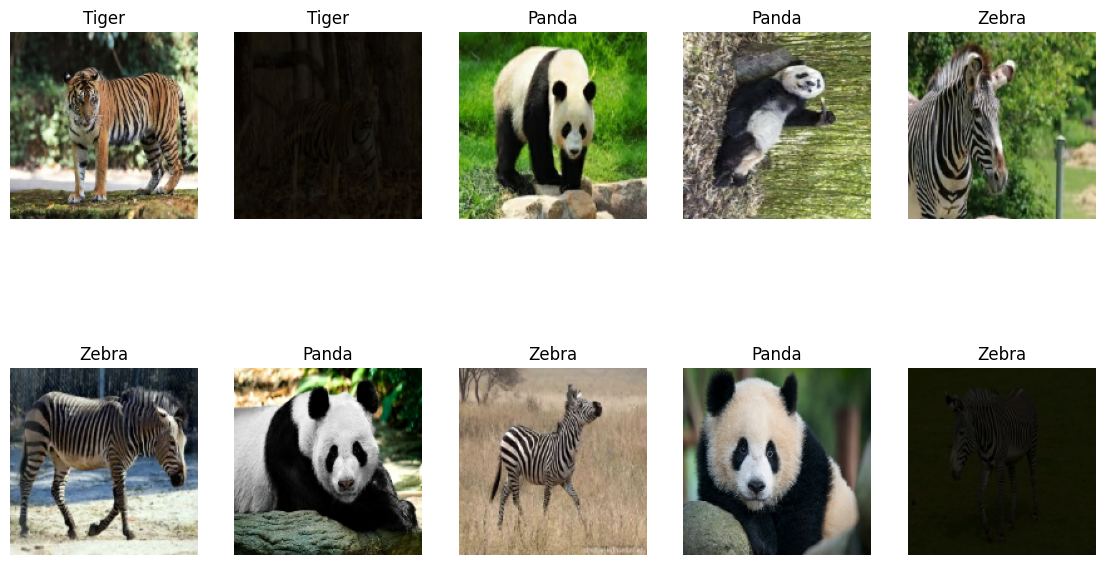

In [4]:
plt.figure(figsize = (14,8))
for images, labels in train_data.take(1):
    for i in range(10):
        ax = plt.subplot(2,5,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.show()

In [5]:
# build the model
num_clasess = 3
model = models.Sequential([layers.Rescaling(1./255, input_shape = (img_height, img_width, 3)), layers.Conv2D(20, 3, padding = 'same', activation = 'relu'), layers.MaxPooling2D(), layers.Conv2D(36, 3, padding = 'same', activation = 'relu'), layers.MaxPooling2D(),layers.Dropout(0.5), layers.Conv2D(68, 3, padding = 'same', activation = 'relu',), layers.MaxPooling2D(),layers.Dropout(0.5), layers.Flatten(), layers.Dense(130, activation = 'relu'),layers.Dense(num_clasess)])
model.summary()

c:\Users\POOJA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 20)   │           560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 36)     │         6,516 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 36)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 37, 37, 36)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 68)     │        22,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 68)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 18, 68)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 22032)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 130)            │     2,864,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           393 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,893,859 (11.04 MB)

 Trainable params: 2,893,859 (11.04 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# compiling
model.compile(optimizer = 'adam', loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True), metrics=['accuracy'])
epochs = 20
history = model.fit(train_data, validation_data=val_data, epochs = epochs)

Epoch 1/20


c:\Users\POOJA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 452ms/step - accuracy: 0.3520 - loss: 1.2500 - val_accuracy: 0.4500 - val_loss: 1.0950
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 444ms/step - accuracy: 0.3832 - loss: 1.0945 - val_accuracy: 0.4750 - val_loss: 1.0974
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 415ms/step - accuracy: 0.4984 - loss: 1.0792 - val_accuracy: 0.3250 - val_loss: 1.0845
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 371ms/step - accuracy: 0.3769 - loss: 1.0558 - val_accuracy: 0.4750 - val_loss: 1.0521
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 368ms/step - accuracy: 0.5265 - loss: 1.0335 - val_accuracy: 0.4250 - val_loss: 0.9819
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 399ms/step - accuracy: 0.5670 - loss: 0.8838 - val_accuracy: 0.6750 - val_loss: 0.8107
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 395ms/step - accuracy: 0.6760 - loss: 0.7349 - val_accuracy: 0.7625 - val_loss: 0.6499
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 413ms/step - accuracy: 0.7508 - loss: 0.6110 - val_accuracy: 0.8125 - val_loss: 0.5600
Epo

In [8]:
# save the model
model.save('tiger_zebra_pands.keras')
print('Model Saved Sucess')

Model Saved Sucess


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
This image mostely belongs to Zebra with a 87.93% confidence


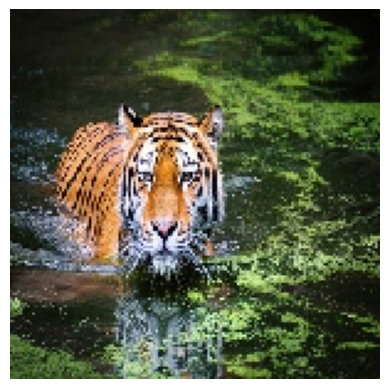

In [20]:
# preditciong new image
test_image = r'C:\Users\POOJA\Downloads\datascience\deep_learnig\tiger_zebra_panda\Tiger\Tiger_2_1.jpg'
if os.path.exists(test_image):
    img = tf.keras.utils.load_img(test_image, target_size = (img_height,img_width))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    # the 0 means: Add a new dimension at position/index 0 — the beginning.
    
    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])
    
    print('This image mostely belongs to {} with a {:.2f}% confidence'.format(class_names[np.argmax(score)], 100*np.max(score)))    
    # .format(class_names[np.argmax(score)], fills the first {}
    # 100*np.max(score), fills the second {:.2f}
    
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print(f'The image not found at{test_image}. Please provide correct path')